# Interband $\varepsilon_2$ of Gold — The Rosei Model

**Purpose.** This notebook walks through every calculation performed by the `rosei_fit_gui.py` fitting tool. It is meant to be read top-to-bottom as a self-contained reference for anyone auditing or extending the code.

**What we model.** The imaginary part of the dielectric function, $\varepsilon_2(\omega)$, of gold in the 1–3.5 eV range. This quantity governs how strongly the metal absorbs light at each photon energy. The dominant features in this range come from **interband transitions** (d-band → sp-band) near the X and L symmetry points of the FCC Brillouin zone, plus a smooth **Drude** (free-electron) background.

**Reference.** Guerrisi, Rosei & Winsemius, *Phys. Rev. B* **12**, 557 (1975), hereafter "Rosei (1975)". Band parameters from Christensen & Seraphin, *Phys. Rev. B* **4**, 3321 (1971).

## 1. Imports and Physical Constants

In [3]:
import numpy as np
from scipy.integrate import quad
from scipy.signal import fftconvolve
import matplotlib.pyplot as plt
from dataclasses import dataclass
import os

# ── Physical constants ──────────────────────────────────────────────────
kB = 8.617e-5   # Boltzmann constant  [eV / K]
C  = 3.81       # ℏ² / (2 mₑ)        [eV·Å²]

# Valley multiplicities (number of equivalent critical points in FCC BZ)
N_X = 6   # X-point
N_L = 8   # L-point

## 2. The Fermi-Dirac Distribution

All energies $\mathcal{E}$ are measured **relative to the Fermi level** ($\mathcal{E}_F = 0$). The occupation probability of a state at energy $\mathcal{E}$ and temperature $T$ is:

$$f(\mathcal{E}, T) = \frac{1}{e^{\mathcal{E}/(k_B T)} + 1}$$

For interband absorption, the relevant factor is $[1 - f(\mathcal{E})]$ — the probability that the **final** (conduction) state is **empty**. The initial d-band state is deep below $\mathcal{E}_F$ and always occupied ($f \approx 1$).

In [4]:
def fermi(E, T):
    """Fermi-Dirac distribution. E measured from E_F = 0."""
    if T == 0:
        return 1.0 if E < 0 else (0.5 if E == 0 else 0.0)
    return 1.0 / (1.0 + np.exp(np.clip(E / (kB * T), -500, 500)))

## 3. Band Structure Near the Critical Points

Rosei approximates the bands as **parabolic** near X and L. The dispersion is written in terms of linearised momenta $u = k_\perp^2$ and $v = k_\parallel^2$:

**X-point** (saddle, $M_1$ critical point):
$$E_c^X = E_{0c} + A_c\, u - B_c\, v, \qquad E_v^X = -E_{0v} - A_v\, u - B_v\, v$$

The minus sign on $B_c$ makes X a saddle point — the conduction band curves **down** along $k_\parallel$.

**L-point** (ellipsoidal minimum, $M_0$ critical point):
$$E_c^L = E_{0c} + A_c\, u + B_c\, v, \qquad E_v^L = -E_{0v} - A_v\, u - B_v\, v$$

Both bands curve the same way — L is a simple minimum.

The band parameters $A_c = C / m_{c\perp}$ and $B_c = C / m_{c\parallel}$ are set by the effective masses (curvatures) of the relativistic band structure.

In [5]:
@dataclass
class XPointParams:
    """X-point (saddle): E_c = E0c + Ac·u - Bc·v"""
    Ac: float; Bc: float; Av: float; Bv: float
    Eg: float; E0c: float = 0.0

    def __post_init__(self):
        self.Abar = self.Ac + self.Av          # Ā = Ac + Av
        self.Bbar = self.Bv - self.Bc          # B̄ = Bv - Bc  (saddle sign)
        self.D    = self.Ac * self.Bv + self.Av * self.Bc   # D = Ac·Bv + Av·Bc

    def E_max(self, hw):  return self.E0c + (self.Ac / self.Abar) * (hw - self.Eg)
    def E_min(self, hw):  return self.E0c - (self.Bc / self.Bbar) * (hw - self.Eg)
    def prefactor(self):  return 1.0 / np.sqrt(self.Abar * abs(self.D))

In [6]:
@dataclass
class LPointParams:
    """L-point (ellipsoidal minimum): E_c = E0c + Ac·u + Bc·v"""
    Ac: float; Bc: float; Av: float; Bv: float
    Eg: float; E0c: float = 0.0

    def __post_init__(self):
        self.Abar = self.Ac + self.Av          # Ā = Ac + Av
        self.Bbar = self.Bc + self.Bv          # B̄ = Bc + Bv  (both positive)
        self.D    = self.Ac * self.Bv - self.Bc * self.Av   # D = Ac·Bv - Bc·Av

    def E_min(self, hw):  return self.E0c + (self.Ac / self.Abar) * (hw - self.Eg)
    def E_max(self, hw):  return self.E0c + (self.Bc / self.Bbar) * (hw - self.Eg)
    def prefactor(self):  return 1.0 / np.sqrt(self.Abar * abs(self.D))

## 3. Band Structure Near the Critical Points

Rosei approximates the bands as **parabolic** near X and L. The dispersion is written in terms of linearised momenta $u = k_\perp^2$ and $v = k_\parallel^2$:

**X-point** (saddle, $M_1$ critical point):
$$E_c^X = E_{0c} + A_c\, u - B_c\, v, \qquad E_v^X = -E_{0v} - A_v\, u - B_v\, v$$

The minus sign on $B_c$ makes X a saddle point — the conduction band curves **down** along $k_\parallel$. **CEDS topology:** Hyperboloid (open surface) — sub-gap transitions are possible.

**L-point** (ellipsoidal minimum, $M_0$ critical point):
$$E_c^L = E_{0c} + A_c\, u + B_c\, v, \qquad E_v^L = -E_{0v} - A_v\, u - B_v\, v$$

Both bands curve the same way — L is a simple minimum. **CEDS topology:** Ellipsoid (closed surface) — transitions only exist above the gap.

The band parameters $A_c = C / m_{c\perp}$ and $B_c = C / m_{c\parallel}$ are set by the effective masses (curvatures) of the relativistic band structure.

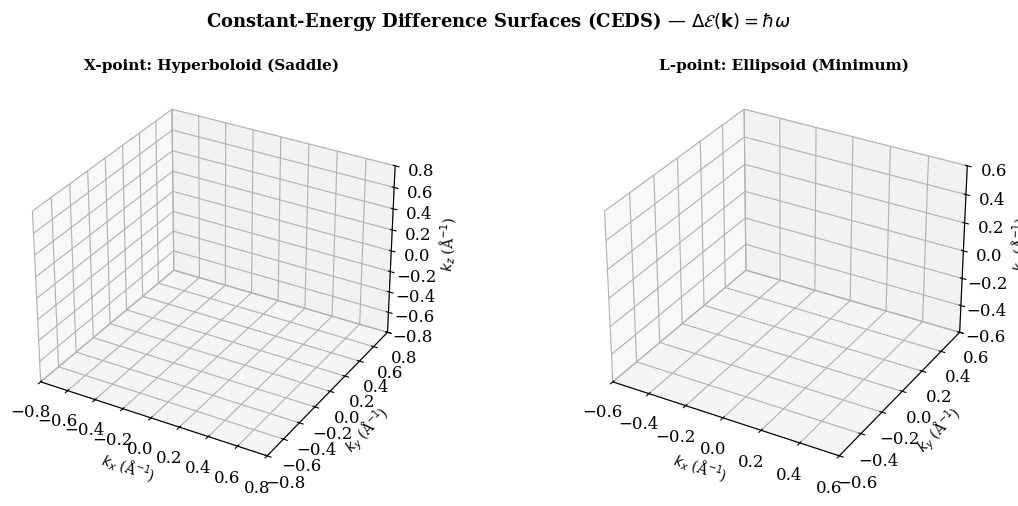

X-point CEDS: Open hyperboloid → sub-gap transitions allowed
L-point CEDS: Closed ellipsoid → only above-gap transitions allowed


In [23]:
# Visualize CEDS Topologies at X and L Points
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial import cKDTree

def plot_ceds_surface(ax, topology_type, hw_eV=1.95, extent=1.0, res=40):
    """Plot constant-energy difference surface (CEDS) for X or L point."""
    # Create k-space grid
    k_range = np.linspace(-extent, extent, res)
    kx, ky, kz = np.meshgrid(k_range, k_range, k_range, indexing='ij')
    
    if topology_type == 'X':
        # X-point saddle: Δε(k) = Ac·(kx² + ky²) - Bc·(kz²)
        Ac, Bc = 0.31 / C, 0.40 / C  # effective mass-like terms
        delta_e = Ac * (kx**2 + ky**2) - Bc * kz**2
        color = '#1f77b4'
        title = "X-point: Hyperboloid (Saddle)"
    else:  # L-point
        # L-point ellipsoid: Δε(k) = Ac·(kx² + ky²) + Bc·(kz²)
        Ac, Bc = 0.24 / C, 0.12 / C
        delta_e = Ac * (kx**2 + ky**2) + Bc * kz**2
        color = '#ff7f0e'
        title = "L-point: Ellipsoid (Minimum)"
    
    # Extract isosurface using simple level-set visualization
    from matplotlib import colors as mcolors
    
    # Find points near the target level
    target = hw_eV
    mask = np.abs(delta_e - target) < 0.05
    if np.any(mask):
        points = np.column_stack(np.where(mask))
        if len(points) > 100:
            # Subsample for visualization
            idx = np.random.choice(len(points), 1000, replace=False)
            points = points[idx]
        
        ax.scatter(kx[tuple(points.T)], ky[tuple(points.T)], kz[tuple(points.T)],
                  c=color, s=1, alpha=0.4, edgecolors='none')
    
    ax.set_xlabel(r'$k_x$ (Å$^{-1}$)', fontsize=10)
    ax.set_ylabel(r'$k_y$ (Å$^{-1}$)', fontsize=10)
    ax.set_zlabel(r'$k_z$ (Å$^{-1}$)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim([-extent, extent])
    ax.set_ylim([-extent, extent])
    ax.set_zlim([-extent, extent])
    ax.grid(alpha=0.2)

# Create figure with two subplots
fig = plt.figure(figsize=(12, 5))
fig.suptitle(r'Constant-Energy Difference Surfaces (CEDS) — $\Delta \mathcal{E}({\bf k}) = \hbar\omega$', 
             fontsize=13, fontweight='bold')

# X-point hyperboloid
ax1 = fig.add_subplot(121, projection='3d')
plot_ceds_surface(ax1, 'X', hw_eV=1.94, extent=0.8)

# L-point ellipsoid
ax2 = fig.add_subplot(122, projection='3d')
plot_ceds_surface(ax2, 'L', hw_eV=2.45, extent=0.6)

plt.tight_layout()
plt.show()

print("X-point CEDS: Open hyperboloid → sub-gap transitions allowed")
print("L-point CEDS: Closed ellipsoid → only above-gap transitions allowed")

In [8]:
# Build parameter objects from effective masses
X = XPointParams(Ac=C/0.31, Bc=C/0.40, Av=C/0.19, Bv=C/0.15, Eg=1.94)
L = LPointParams(Ac=C/0.24, Bc=C/0.12, Av=C/0.70, Bv=C/1.03, Eg=2.45)

P_RATIO_SQ = 0.370    # |P_X / P_L|²
T_eff      = 600.0    # Effective electronic temperature [K]

for name, p in [("X", X), ("L", L)]:
    print(f"{name}-point:")
    print(f"  Ac={p.Ac:.2f}  Bc={p.Bc:.2f}  Av={p.Av:.2f}  Bv={p.Bv:.2f}")
    print(f"  Ā={p.Abar:.2f}  B̄={p.Bbar:.2f}  D={p.D:.2f}  Eg={p.Eg} eV")
    print(f"  prefactor = 1/√(Ā·|D|) = {p.prefactor():.4f}")
    print()

X-point:
  Ac=12.29  Bc=9.53  Av=20.05  Bv=25.40
  Ā=32.34  B̄=15.88  D=503.18  Eg=1.94 eV
  prefactor = 1/√(Ā·|D|) = 0.0078

L-point:
  Ac=15.88  Bc=31.75  Av=5.44  Bv=3.70
  Ā=21.32  B̄=35.45  D=-114.09  Eg=2.45 eV
  prefactor = 1/√(Ā·|D|) = 0.0203



## 5. The JDOS Integral

Starting from Fermi's golden rule for direct interband transitions and performing the change of variables from $\mathbf{k}$-space to energy space (see Appendix A8), we arrive at a 1D integral over conduction-band energy $\mathcal{E}$:

$$J_P(\hbar\omega, T) = \frac{1}{\sqrt{\bar{A}_P |D_P|}} \int_{\mathcal{E}_{\min}^P}^{\mathcal{E}_{\max}^P} \frac{[1 - f(\mathcal{E}, T)]}{\sqrt{g_P(\mathcal{E})}} \; d\mathcal{E}$$

The singularity $1/\sqrt{g}$ differs between X and L:

| | X (saddle) | L (ellipsoid) |
|:--|:--|:--|
| Singularity | $1/\sqrt{\mathcal{E}_{\max} - \mathcal{E}}$ | $1/\sqrt{\mathcal{E} - \mathcal{E}_{\min}}$ |

Both are integrable ($\int 1/\sqrt{x}\,dx = 2\sqrt{x}$), but naive quadrature struggles. We remove the singularity by substitution.

## 6. Regularised Quadrature

**X-point** — singularity at $\mathcal{E}_{\max}$, substitute $t = \sqrt{\mathcal{E}_{\max} - \mathcal{E}}$:
$$\int_{\mathcal{E}_{\min}}^{\mathcal{E}_{\max}} \frac{[1-f(\mathcal{E})]\,d\mathcal{E}}{\sqrt{\mathcal{E}_{\max}-\mathcal{E}}} \;\longrightarrow\; \int_0^{\sqrt{\mathcal{E}_{\max}-\mathcal{E}_{\min}}} 2\,[1-f(\mathcal{E}_{\max}-t^2)]\,dt$$

**Sub-gap transitions at X (Rosei 1975).** Because X is a saddle point ($M_1$), the CEDS is open — interband transitions exist even for $\hbar\omega < \mathcal{E}_g^X$. The formula for $\mathcal{E}_{\max}^X$ remains valid (it simply goes below $E_F$), and the Fermi factor $[1-f]$ naturally suppresses deeply occupied final states. Following Rosei, we replace the geometric lower limit with a fixed thermal cutoff: $\mathcal{E}_{\min}^X = -20\,k_BT$.

**L-point** — singularity at $\mathcal{E}_{\min}$, substitute $t = \sqrt{\mathcal{E} - \mathcal{E}_{\min}}$:
$$\int_{\mathcal{E}_{\min}}^{\mathcal{E}_{\max}} \frac{[1-f(\mathcal{E})]\,d\mathcal{E}}{\sqrt{\mathcal{E}-\mathcal{E}_{\min}}} \;\longrightarrow\; \int_0^{\sqrt{\mathcal{E}_{\max}-\mathcal{E}_{\min}}} 2\,[1-f(\mathcal{E}_{\min}+t^2)]\,dt$$

L is an $M_0$ critical point — no transitions exist below $\mathcal{E}_g^L$, so the geometric limits are kept.

In [9]:
def _interband_integral(hw, T, p, is_L=False):
    """Compute the regularised 1D JDOS integral for a single photon energy hw."""
    if is_L:
        # L-point (M0): no transitions below gap
        if hw <= p.Eg:
            return 0.0
        e_min, e_max = p.E_min(hw), p.E_max(hw)
        if e_max <= e_min:
            return 0.0
        t_max = np.sqrt(e_max - e_min)
        integrand = lambda t: 2.0 * (1.0 - fermi(e_min + t**2, T))
    else:
        # X-point (M1 saddle): sub-gap transitions exist.
        # Upper limit from geometry; lower limit = -20 kBT (Rosei 1975).
        e_max = p.E_max(hw)
        e_min = -20.0 * kB * T if T > 0 else -0.1
        if e_max <= e_min:
            return 0.0
        t_max = np.sqrt(e_max - e_min)
        integrand = lambda t: 2.0 * (1.0 - fermi(e_max - t**2, T))

    result, _ = quad(integrand, 0, t_max)
    return p.prefactor() * result

## 7. From Transition Rate to $\varepsilon_2$: the $1/\omega^2$ Factor

The JDOS integral $J_P$ gives us the **transition rate** $\Gamma(\omega)$. To convert to the imaginary dielectric function we need the standard relation (e.g., Wooten, *Optical Properties of Solids*):

$$\varepsilon_2(\omega) = \frac{4\pi^2 e^2}{m_e^2 \omega^2} \sum_P N_P\, |P_P|^2\, J_P(\omega)$$

The $1/\omega^2$ comes from the electromagnetic coupling between the light field and the induced polarisation. In our code it appears as:

```python
raw_x[i] = N_X * P_RATIO_SQ * _interband_integral(hw, T, X) / hw**2
```

Since we use $|P_X/P_L|^2$ as the ratio and absorb $|P_L|^2$ (along with all other prefactors) into the **Scale** parameter, what the code computes is:

$$\varepsilon_2^{\text{inter}}(\omega) = \text{Scale} \times \frac{1}{\omega^2} \Big[ |P_X/P_L|^2 \cdot N_X \cdot J_X + N_L \cdot J_L \Big]$$

## 8. Lorentzian Broadening

The bare JDOS has a hard onset at $\mathcal{E}_g$ — a sharp step. In reality, electronic states have finite lifetimes due to electron-electron scattering, electron-phonon coupling, and disorder. This is modelled by convolving $\varepsilon_2(\omega)$ with a Lorentzian of half-width $\Gamma$:

$$\varepsilon_2^{\text{broad}}(\omega) = \int \varepsilon_2(\omega') \; \frac{\Gamma/\pi}{(\omega - \omega')^2 + \Gamma^2}\; d\omega'$$

This is equivalent to giving each transition a spectral weight of width $\Gamma \sim \hbar / \tau$ instead of a perfect $\delta$-function.

**Independent broadening.** The GUI applies separate $\Gamma_X$ and $\Gamma_L$ because the quasiparticle lifetimes at X and L can differ (different band velocities, different phase space for scattering). The X and L contributions are broadened independently, then summed.

In [10]:
def broaden(y, x, gamma):
    """Convolve y(x) with a normalised Lorentzian of HWHM gamma.
    Implemented as FFT convolution for speed."""
    if gamma < 1e-4:
        return y.copy()
    dx = x[1] - x[0]
    x_k = x - x[len(x) // 2]
    kernel = (gamma / np.pi) / (x_k**2 + gamma**2) * dx
    return fftconvolve(y, kernel, mode="same")

## 9. The Drude (Free-Electron) Contribution

Below ~2 eV, the interband model alone underestimates $\varepsilon_2$ because **intraband** (free-electron) absorption contributes. The Drude model gives:

$$\varepsilon_2^{\text{Drude}}(\omega) = \frac{\omega_p^2 \, \gamma_D}{\omega(\omega^2 + \gamma_D^2)}$$

In the optical regime $\omega \gg \gamma_D$ (photon energies 1–3 eV vs $\hbar\gamma_D \approx 0.07$ eV), this simplifies to:

$$\varepsilon_2^{\text{Drude}}(\omega) \approx \frac{A_D}{\omega^3}, \qquad A_D \equiv \omega_p^2 \cdot \gamma_D$$

For gold: $\hbar\omega_p \approx 9$ eV, $\hbar\gamma_D \approx 0.07$ eV → $A_D \approx 5.7$ eV³ (room temperature). At elevated $T$, $\gamma_D$ increases with electron-phonon scattering, so $A_D$ can be 8–10 eV³.

**Important:** The Drude term is in **absolute** $\varepsilon_2$ units — it is **not** multiplied by the interband Scale factor.

In [11]:
def compute_drude(hw, A_drude):
    """Drude ε₂ in the high-frequency limit: A_D / ω³"""
    return A_drude / hw**3

## 10. The Scale Factor and Why We Need It

The full textbook formula for $\varepsilon_2$ contains prefactors like $e^2 / (\varepsilon_0 m_e^2)$ and the absolute squared matrix element $|P_L|^2$. Rosei's model does **not** compute these — it computes only the **spectral shape** (where the absorption turns on, how the X and L contributions overlap). The absolute magnitude is unknown because:

1. $|P_{cv}|^2$ requires knowledge of the Bloch wavefunctions (an ab initio calculation).
2. The parabolic approximation is only valid near the critical points, not across the full BZ.
3. The BZ volume normalisation depends on exactly how far the parabolic fit extends.

**Scale** absorbs all of these into a single fitted number. It is the only truly "free" parameter in the model (aside from $A_D$ which is physically constrained).

**Why $|P_X/P_L|^2$ is separate.** The ratio affects the **lineshape** — it controls whether the X or L onset is more prominent. Scale affects only the overall height. They are independent degrees of freedom. Rosei reports $|P_X/P_L|^2 = 0.370$ from his fit; individual values of $|P_X|^2$ and $|P_L|^2$ are absorbed into Scale.

## 11. The Full Model — Assembly

Putting it all together, the complete model evaluated by the GUI is:

$$\boxed{\varepsilon_2(\omega) = \underbrace{\text{Scale} \times \frac{1}{\omega^2}\Big[|P_X/P_L|^2 \cdot N_X \cdot \widetilde{J}_X(\omega) + N_L \cdot \widetilde{J}_L(\omega)\Big]}_{\text{interband (X + L)}} + \underbrace{\frac{A_D}{\omega^3}}_{\text{Drude}}}$$

where $\widetilde{J}_P$ denotes the broadened JDOS (convolved with Lorentzian of width $\Gamma_P$).

The four subplot datasets in the GUI correspond to:
- **X only:** $\text{Scale} \times (|P_X/P_L|^2 \cdot N_X \cdot \widetilde{J}_X) / \omega^2$
- **L only:** $\text{Scale} \times (N_L \cdot \widetilde{J}_L) / \omega^2$
- **X + L:** sum of the above
- **X + L + Drude:** X + L + $A_D / \omega^3$

In [12]:
def compute_interband(hw_ext, T, P_ratio_sq, Gamma_X, Gamma_L, xp, lp):
    """Compute broadened X and L contributions on the extended energy grid.
    Returns (total, X_contrib, L_contrib) cropped to the display window."""
    raw_x = np.empty(len(hw_ext))
    raw_l = np.empty_like(raw_x)

    for i, hw in enumerate(hw_ext):
        raw_x[i] = N_X * P_ratio_sq * _interband_integral(hw, T, xp) / hw**2
        raw_l[i] = N_L              * _interband_integral(hw, T, lp, is_L=True) / hw**2

    # Broaden X and L independently (different lifetimes)
    bx = broaden(raw_x, hw_ext, Gamma_X)[DISP_MASK]
    bl = broaden(raw_l, hw_ext, Gamma_L)[DISP_MASK]

    return (bx + bl, bx, bl)

## 12. Energy Grid and Experimental Data

We compute on an **extended** grid (0.5–4.0 eV) to give the Lorentzian convolution room to decay, then crop to the **display** window (1.0–3.2 eV) for comparison with data.

The experimental data is digitised from Figure 8 of Guerrisi, Rosei & Winsemius (1975):
- `a_e2_X.txt` — X-point contribution only (22 points)
- `b_e2_L.txt` — L-point contribution only (26 points)
- `c_e2_X_L.txt` — X + L combined (45 points)
- `d_e2_X_L_Drude.txt` — full $\varepsilon_2$ including Drude (198 points, 1.0–3.5 eV)

In [13]:
# ── Energy grid ──────────────────────────────────────────────────────────
HW_EXT = np.linspace(0.5, 4.0, 400)       # extended grid (broadening padding)
HW_LO, HW_HI = 1.0, 3.2                   # display window
DISP_MASK = (HW_EXT >= HW_LO) & (HW_EXT <= HW_HI)
HW_DISP = HW_EXT[DISP_MASK]

print(f"Extended grid: {len(HW_EXT)} points, {HW_EXT[0]:.1f}–{HW_EXT[-1]:.1f} eV")
print(f"Display grid:  {len(HW_DISP)} points, {HW_LO}–{HW_HI} eV")

Extended grid: 400 points, 0.5–4.0 eV
Display grid:  251 points, 1.0–3.2 eV


In [14]:
# ── Load experimental data ───────────────────────────────────────────────
def _load(fn):
    arr = np.loadtxt(fn, delimiter=",", skiprows=1)
    return arr[arr[:, 0].argsort()]

data = {
    "X":   _load("a_e2_X.txt"),
    "L":   _load("b_e2_L.txt"),
    "XL":  _load("c_e2_X_L.txt"),
    "XLD": _load("d_e2_X_L_Drude.txt"),
}

for key, d in data.items():
    print(f"{key:>3s}: {len(d):3d} points, {d[0,0]:.3f}–{d[-1,0]:.3f} eV")

  X:  22 points, 1.840–2.748 eV
  L:  26 points, 1.897–2.740 eV
 XL:  45 points, 1.853–2.743 eV
XLD: 145 points, 1.013–3.493 eV


## 13. Computing the Model Curves

We now evaluate the model with the Christensen & Seraphin parameters, then fit Scale and $A_D$ by linear least squares against the XLD data.

In [15]:
# ── Parameters ───────────────────────────────────────────────────────────
Gamma_X = 0.07   # eV  (broadening for X)
Gamma_L = 0.07   # eV  (broadening for L)

# ── Compute raw interband contributions ─────────────────────────────────
tot, cx, cl = compute_interband(HW_EXT, T_eff, P_RATIO_SQ, Gamma_X, Gamma_L, X, L)

print(f"Interband computed: {len(HW_DISP)} display points")
print(f"  X peak  = {np.max(cx):.4f}  (unscaled)")
print(f"  L peak  = {np.max(cl):.4f}  (unscaled)")
print(f"  XL peak = {np.max(tot):.4f} (unscaled)")

Interband computed: 251 display points
  X peak  = 0.0024  (unscaled)
  L peak  = 0.0099  (unscaled)
  XL peak = 0.0121 (unscaled)


## 14. Fitting Scale and $A_D$ by Least Squares

Since $\varepsilon_2 = \text{Scale} \times \text{tot}(\omega) + A_D / \omega^3$ is **linear** in Scale and $A_D$, we can solve for them exactly via ordinary least squares — no iterative optimizer needed.

In [16]:
# Interpolate model onto the XLD data points
d_xld = data["XLD"]
d_hw, d_e2 = d_xld[:, 0], d_xld[:, 1]

tot_at_data = np.interp(d_hw, HW_DISP, tot)
drude_shape = 1.0 / d_hw**3

# Build the linear system:  d_e2 ≈ Scale * tot_at_data + A_D * drude_shape
A_mat = np.column_stack([tot_at_data, drude_shape])
result, _, _, _ = np.linalg.lstsq(A_mat, d_e2, rcond=None)
Scale, A_drude = result

print(f"Fitted Scale  = {Scale:.1f}")
print(f"Fitted A_D    = {A_drude:.2f} eV³")
print(f"\nExpected A_D  ≈ ωp²·γ_D = 9²×0.07 ≈ 5.7 eV³ (room T)")
print(f"Higher values indicate elevated effective temperature.")

Fitted Scale  = 461.6
Fitted A_D    = 8.33 eV³

Expected A_D  ≈ ωp²·γ_D = 9²×0.07 ≈ 5.7 eV³ (room T)
Higher values indicate elevated effective temperature.


## 15. $R^2$ Score

The coefficient of determination measures how well the model reproduces each dataset:

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

$R^2 = 1$ is a perfect fit; $R^2 = 0$ means the model is no better than a horizontal line at the mean.

In [17]:
def r_squared(d_hw, d_e2, m_hw, m_e2):
    """R² between data (d) and model (m), interpolating model onto data grid."""
    mi = np.interp(d_hw, m_hw, m_e2)
    ss_res = np.sum((d_e2 - mi) ** 2)
    ss_tot = np.sum((d_e2 - np.mean(d_e2)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 1e-30 else 0.0

# Build the four model curves
drude = compute_drude(HW_DISP, A_drude)
curves = {
    "X":   Scale * cx,
    "L":   Scale * cl,
    "XL":  Scale * tot,
    "XLD": Scale * tot + drude,
}

# Score each
for key in ("X", "L", "XL", "XLD"):
    r2 = r_squared(data[key][:, 0], data[key][:, 1], HW_DISP, curves[key])
    print(f"R²({key:>3s}) = {r2:.4f}")

R²(  X) = 0.7290
R²(  L) = 0.9894
R²( XL) = 0.9664
R²(XLD) = 0.9863


## 16. Four-Panel Comparison with Data

The same layout as the GUI: four subplots showing each component separately.

In [18]:
def add_wavelength_axis(ax):
    """Add a secondary top x-axis showing wavelength (nm) = 1239.8 / E(eV)."""
    ax2 = ax.secondary_xaxis("top", functions=(lambda e: 1239.8 / e,
                                                lambda w: 1239.8 / w))
    ax2.set_xlabel("λ (nm)")
    return ax2

/var/folders/8_/lb82j87n40q1pn140s68mgz80000gn/T/ipykernel_88147/61176413.py:4: RuntimeWarning: divide by zero encountered in divide
  lambda w: 1239.8 / w))


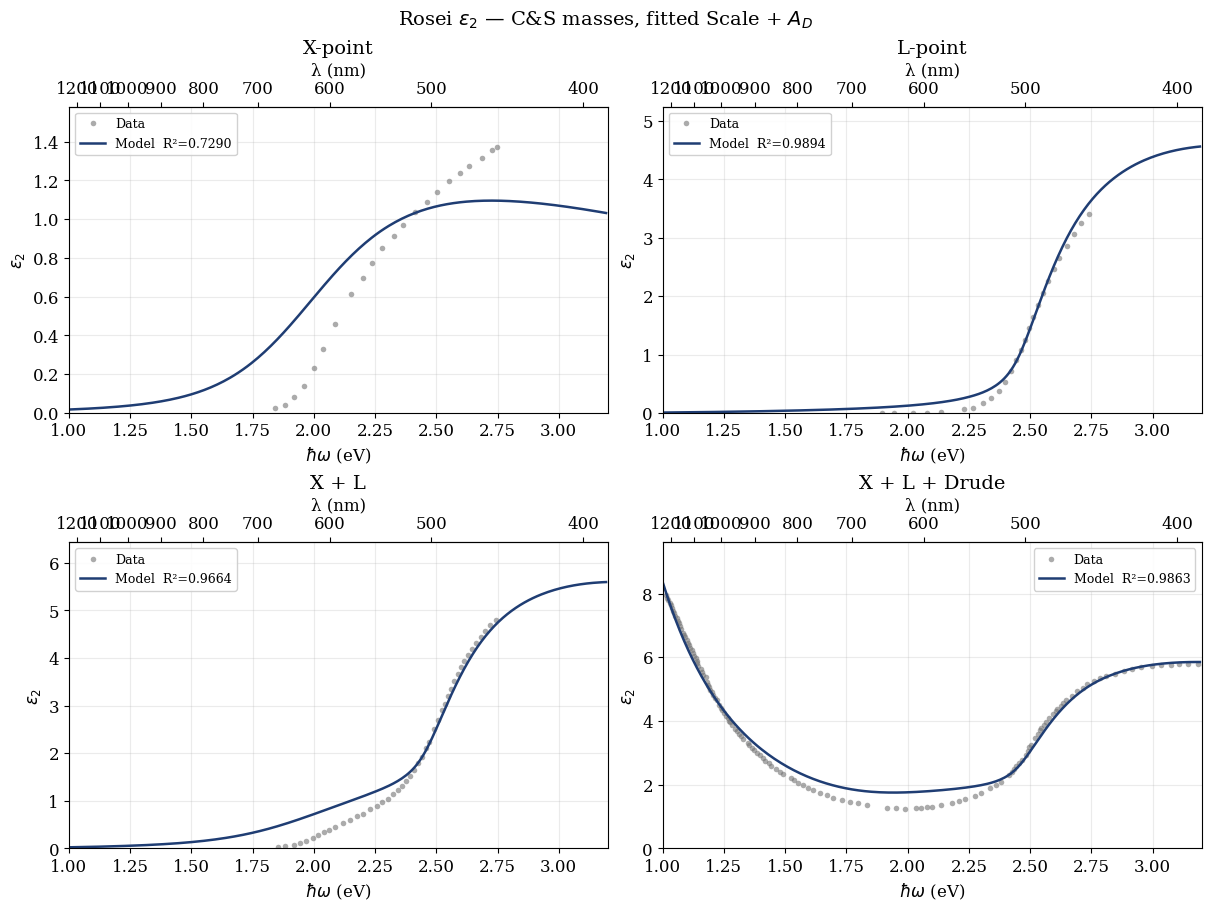

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
fig.suptitle(r"Rosei $\varepsilon_2$ — C&S masses, fitted Scale + $A_D$", fontsize=14)

titles = {"X": "X-point", "L": "L-point", "XL": "X + L", "XLD": "X + L + Drude"}
positions = {"X": (0, 0), "L": (0, 1), "XL": (1, 0), "XLD": (1, 1)}

for key, (r, c) in positions.items():
    ax = axes[r, c]
    d = data[key]
    r2 = r_squared(d[:, 0], d[:, 1], HW_DISP, curves[key])

    ax.plot(d[:, 0], d[:, 1], "o", color="0.45", ms=4, alpha=0.6,
            markeredgewidth=0, label="Data")
    ax.plot(HW_DISP, curves[key], "-", color="#1f3d73", lw=1.8,
            label=f"Model  R²={r2:.4f}")

    ax.set_xlabel(r"$\hbar\omega$ (eV)")
    ax.set_ylabel(r"$\varepsilon_2$")
    ax.set_title(titles[key])
    ax.set_xlim(HW_LO, HW_HI)
    ymax = max(np.max(d[:, 1]), np.max(curves[key])) * 1.15
    ax.set_ylim(0, max(ymax, 0.5))
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(alpha=0.25)
    add_wavelength_axis(ax)

plt.show()

## 17. Effect of Broadening

To see what the broadening does, we compare $\Gamma = 0$ (bare JDOS, sharp onset) vs $\Gamma = 0.07$ eV (physical lifetime).

/var/folders/8_/lb82j87n40q1pn140s68mgz80000gn/T/ipykernel_88147/61176413.py:4: RuntimeWarning: divide by zero encountered in divide
  lambda w: 1239.8 / w))


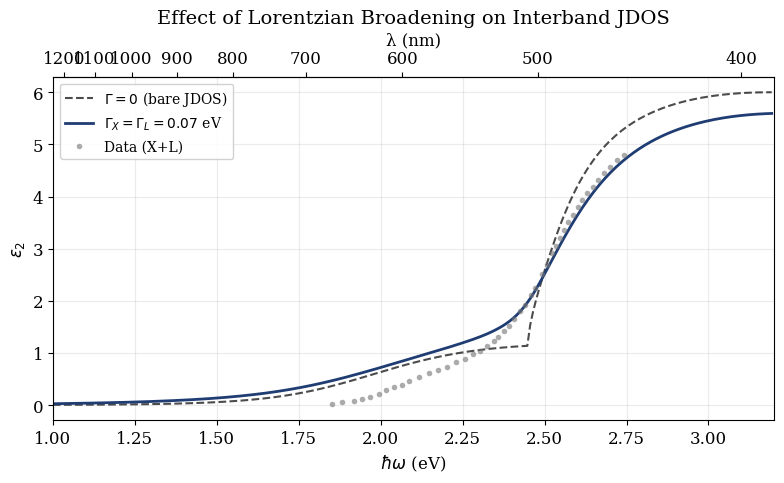

In [20]:
# Bare JDOS (no broadening)
tot_bare, cx_bare, cl_bare = compute_interband(HW_EXT, T_eff, P_RATIO_SQ, 0.0, 0.0, X, L)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(HW_DISP, Scale * tot_bare, "k--", lw=1.5, alpha=0.7,
        label=r"$\Gamma = 0$ (bare JDOS)")
ax.plot(HW_DISP, Scale * tot, "-", color="#1f3d73", lw=2,
        label=rf"$\Gamma_X = \Gamma_L = {Gamma_X}$ eV")

d = data["XL"]
ax.plot(d[:, 0], d[:, 1], "o", color="0.45", ms=4, alpha=0.6,
        markeredgewidth=0, label="Data (X+L)")

ax.set_xlabel(r"$\hbar\omega$ (eV)")
ax.set_ylabel(r"$\varepsilon_2$")
ax.set_title("Effect of Lorentzian Broadening on Interband JDOS")
ax.set_xlim(HW_LO, HW_HI)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(alpha=0.25)
add_wavelength_axis(ax)
plt.tight_layout()
plt.show()

## 18. Decomposition: Interband vs Drude

This shows how the Drude tail fills in the low-energy region where interband transitions alone underpredict $\varepsilon_2$.

/var/folders/8_/lb82j87n40q1pn140s68mgz80000gn/T/ipykernel_88147/61176413.py:4: RuntimeWarning: divide by zero encountered in divide
  lambda w: 1239.8 / w))


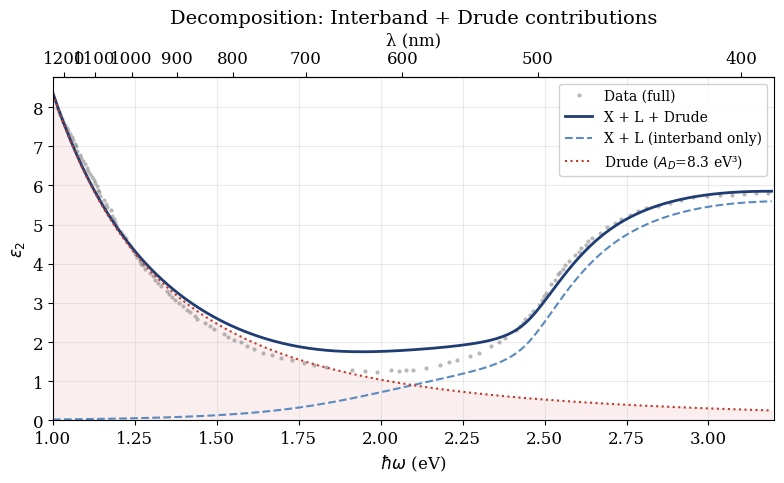

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

d = data["XLD"]
ax.plot(d[:, 0], d[:, 1], "o", color="0.45", ms=3, alpha=0.5,
        markeredgewidth=0, label="Data (full)")

ax.plot(HW_DISP, curves["XLD"], "-", color="#1f3d73", lw=2, label="X + L + Drude")
ax.plot(HW_DISP, curves["XL"],  "--", color="#5a8abf", lw=1.5, label="X + L (interband only)")
ax.plot(HW_DISP, drude, ":", color="#c0392b", lw=1.5,
        label=f"Drude ($A_D$={A_drude:.1f} eV³)")

ax.fill_between(HW_DISP, 0, drude, color="#c0392b", alpha=0.08)

ax.set_xlabel(r"$\hbar\omega$ (eV)")
ax.set_ylabel(r"$\varepsilon_2$")
ax.set_title("Decomposition: Interband + Drude contributions")
ax.set_xlim(HW_LO, HW_HI)
ax.set_ylim(0)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(alpha=0.25)
add_wavelength_axis(ax)
plt.tight_layout()
plt.show()

## 19. Summary of Model Parameters

| Parameter | Value | Source | Role |
|:--|:--|:--|:--|
| Effective masses (8) | see §4 | Christensen & Seraphin (1971) | Band curvatures at X and L |
| $\mathcal{E}_g^X = 1.94$ eV | fixed | Rosei (1975) | X-point interband threshold |
| $\mathcal{E}_g^L = 2.45$ eV | fixed | Rosei (1975) | L-point interband threshold |
| $\|P_X/P_L\|^2 = 0.370$ | fixed | Rosei (1975) | Relative X vs L weight |
| $T_{\text{eff}} = 600$ K | fixed | Rosei (1975) | Electronic temperature |
| $\Gamma_X, \Gamma_L = 0.07$ eV | adjustable | Physical estimate | Quasiparticle lifetime broadening |
| **Scale** | **fitted** | — | Overall interband amplitude (unknown prefactor) |
| **$A_D$** | **fitted** | $\approx \omega_p^2 \gamma_D$ | Drude background strength |

Only **Scale** and **$A_D$** are truly free parameters when the band structure is fixed to literature values. The GUI additionally allows adjusting all masses, gaps, and broadening for exploration.

Figure beautifully rendered and saved as CEDS_BZ_topology.pdf


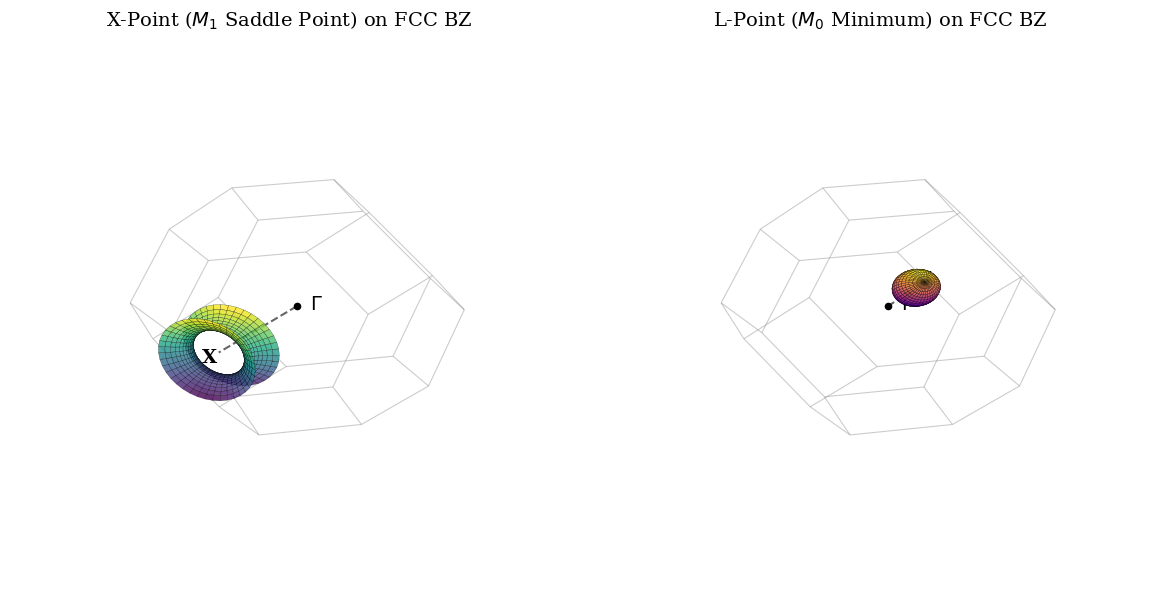

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import itertools

# --- Academic Style Configuration ---
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.titlesize': 14,
})

fig = plt.figure(figsize=(12, 6))

# ==========================================
# 1. GENERATE THE FCC BRILLOUIN ZONE
# ==========================================
# The FCC BZ is a truncated octahedron. In normalized units (where X is at distance 1),
# the 24 vertices are all 3D permutations of (+-1, +-0.5, 0).
v_base = [
    (1, 0.5, 0), (1, -0.5, 0), (-1, 0.5, 0), (-1, -0.5, 0),
    (1, 0, 0.5), (1, 0, -0.5), (-1, 0, 0.5), (-1, 0, -0.5),
    (0.5, 1, 0), (-0.5, 1, 0), (0.5, -1, 0), (-0.5, -1, 0),
    (0.5, 0, 1), (-0.5, 0, 1), (0.5, 0, -1), (-0.5, 0, -1),
    (0, 1, 0.5), (0, 1, -0.5), (0, -1, 0.5), (0, -1, -0.5),
    (0, 0.5, 1), (0, -0.5, 1), (0, 0.5, -1), (0, -0.5, -1)
]

# The edge length of this specific truncated octahedron is exactly sqrt(0.5)
target_dist = np.sqrt(0.5)
edges = []
for i in range(len(v_base)):
    for j in range(i + 1, len(v_base)):
        dist = np.linalg.norm(np.array(v_base[i]) - np.array(v_base[j]))
        if np.isclose(dist, target_dist):
            edges.append((v_base[i], v_base[j]))

def plot_bz_wireframe(ax):
    """Plots the elegant BZ wireframe."""
    line_collection = Line3DCollection(edges, colors='gray', linewidths=0.8, alpha=0.4)
    ax.add_collection3d(line_collection)
    ax.scatter(0, 0, 0, color='black', s=20) # Gamma point
    ax.text(0, 0.1, 0, r'$\Gamma$', fontsize=14, fontweight='bold')

# ==========================================
# 2. LEFT SUBPLOT: X-Point (Hyperboloid)
# ==========================================
ax1 = fig.add_subplot(121, projection='3d')
plot_bz_wireframe(ax1)

# X-point is at the center of the square face along the x-axis
X_point = np.array([1, 0, 0])

# Parametric Hyperboloid aligned along Gamma-X (x-axis)
u = np.linspace(0, 2 * np.pi, 40)
v = np.linspace(-1.2, 1.2, 20)
U, V = np.meshgrid(u, v)

# k_parallel mapped to x, k_perp mapped to y, z
x_h = X_point[0] + 0.1 * np.sinh(V)
y_h = X_point[1] + 0.2 * np.cosh(V) * np.cos(U)
z_h = X_point[2] + 0.2 * np.cosh(V) * np.sin(U)

ax1.plot_surface(x_h, y_h, z_h, cmap='viridis', alpha=0.8, edgecolor='black', linewidth=0.2)
ax1.plot([0, 1], [0, 0], [0, 0], 'k--', alpha=0.6) # Gamma to X line
ax1.text(1.2, 0, 0, 'X', fontsize=14, fontweight='bold')

ax1.set_title('X-Point ($M_1$ Saddle Point) on FCC BZ')
ax1.set_xlim([-1.2, 1.2]); ax1.set_ylim([-1.2, 1.2]); ax1.set_zlim([-1.2, 1.2])
ax1.axis('off') # Clean academic look
ax1.view_init(elev=20, azim=30)

# ==========================================
# 3. RIGHT SUBPLOT: L-Point (Ellipsoid)
# ==========================================
ax2 = fig.add_subplot(122, projection='3d')
plot_bz_wireframe(ax2)

# L-point is at the center of the hexagonal face in the first octant
L_point = np.array([0.5, 0.5, 0.5])
gamma_L_vec = L_point / np.linalg.norm(L_point)

# Parametric Ellipsoid initially aligned along Z
u2 = np.linspace(0, 2 * np.pi, 40)
v2 = np.linspace(0, np.pi, 20)
U2, V2 = np.meshgrid(u2, v2)

X_e = 0.15 * np.sin(V2) * np.cos(U2)
Y_e = 0.15 * np.sin(V2) * np.sin(U2)
Z_e = 0.25 * np.cos(V2) # Elongated along longitudinal axis

# Rotate Ellipsoid to align Z-axis with the Gamma-L vector (1,1,1)
z_axis = np.array([0, 0, 1])
cross_prod = np.cross(z_axis, gamma_L_vec)
cos_angle = np.dot(z_axis, gamma_L_vec)
kmat = np.array([[0, -cross_prod[2], cross_prod[1]], 
                 [cross_prod[2], 0, -cross_prod[0]], 
                 [-cross_prod[1], cross_prod[0], 0]])
R = np.eye(3) + kmat + kmat.dot(kmat) * ((1 - cos_angle) / (np.linalg.norm(cross_prod) ** 2))

pts = np.vstack([X_e.flatten(), Y_e.flatten(), Z_e.flatten()])
rot_pts = R.dot(pts)
X_rot = rot_pts[0].reshape(X_e.shape) + L_point[0]
Y_rot = rot_pts[1].reshape(Y_e.shape) + L_point[1]
Z_rot = rot_pts[2].reshape(Z_e.shape) + L_point[2]

ax2.plot_surface(X_rot, Y_rot, Z_rot, cmap='plasma', alpha=0.8, edgecolor='black', linewidth=0.2)
ax2.plot([0, L_point[0]], [0, L_point[1]], [0, L_point[2]], 'k--', alpha=0.6) # Gamma to L line
ax2.text(0.6, 0.6, 0.6, 'L', fontsize=14, fontweight='bold')

ax2.set_title('L-Point ($M_0$ Minimum) on FCC BZ')
ax2.set_xlim([-1.2, 1.2]); ax2.set_ylim([-1.2, 1.2]); ax2.set_zlim([-1.2, 1.2])
ax2.axis('off')
ax2.view_init(elev=20, azim=30)

plt.tight_layout()
plt.savefig('CEDS_BZ_topology.pdf', dpi=300, bbox_inches='tight', transparent=True)
print("Figure beautifully rendered and saved as CEDS_BZ_topology.pdf")